1. Load dataset

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('diabetes.csv')

# Check the first few rows
print(df.head())

   preg  plas  pres  skin  insu  mass   pedi  age            class
0     6   148    72    35     0  33.6  0.627   50  tested_positive
1     1    85    66    29     0  26.6  0.351   31  tested_negative
2     8   183    64     0     0  23.3  0.672   32  tested_positive
3     1    89    66    23    94  28.1  0.167   21  tested_negative
4     0   137    40    35   168  43.1  2.288   33  tested_positive


2. Define and apply IQR-based outlier detection

In [8]:
# Search numerical columns (everything except the 'class')
numerical_features = df.drop(columns=['class'])

# 1. Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = numerical_features.quantile(0.25)
Q3 = numerical_features.quantile(0.75)

# 2. Compute the IQR
IQR = Q3 - Q1

# 3. Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR for each feature:\n", IQR)

IQR for each feature:
 preg      5.0000
plas     41.2500
pres     18.0000
skin     32.0000
insu    127.2500
mass      9.3000
pedi      0.3825
age      17.0000
dtype: float64


3.  Replace outliers with NA and select complete cases

In [9]:
import numpy as np

# 1. Handle Zeros
# 0 = data is missing.
cols_with_zeros = ['plas', 'pres', 'skin', 'insu', 'mass']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# 2. Replace Outliers with NA
# use bounds calculated in the previous step
df_cleaned = df.copy()
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    # Mark values below lower_bound or above upper_bound as NaN
    df_cleaned.loc[(df_cleaned[col] < lower_bound[col]) | (df_cleaned[col] > upper_bound[col]), col] = np.nan

# 3. Select complete cases
# Drop any row that has at least one NaN
df_final = df_cleaned.dropna()

print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(df_final)}")

Original rows: 768
Rows after cleaning: 332


3.1. Describe single features

In [10]:
# This gives the summary stats for cleaned dataset
print("Summary Statistics (Cleaned Data):")
print(df_final.describe())


Summary Statistics (Cleaned Data):
             preg        plas        pres        skin        insu        mass  \
count  332.000000  332.000000  332.000000  332.000000  332.000000  332.000000   
mean     3.177711  118.903614   70.722892   28.424699  126.897590   32.426807   
std      3.023830   29.214227   11.403941   10.316021   66.660852    6.380974   
min      0.000000   56.000000   38.000000    7.000000   15.000000   18.200000   
25%      1.000000   97.750000   62.000000   20.000000   74.750000   27.800000   
50%      2.000000  114.500000   70.000000   28.000000  115.500000   32.850000   
75%      5.000000  136.250000   78.000000   36.000000  168.500000   36.500000   
max     13.000000  198.000000  106.000000   60.000000  318.000000   49.700000   

             pedi         age  
count  332.000000  332.000000  
mean     0.473250   30.225904  
std      0.252859    9.418446  
min      0.085000   21.000000  
25%      0.267750   23.000000  
50%      0.430000   27.000000  
75%      0.

4. Rank features using mutual information

In [11]:
from sklearn.feature_selection import mutual_info_classif

# 1. Separate the features (X) from the target (y)
X = df_final.drop(columns=['class'])
y = df_final['class']

# 2. Calculate Mutual Information
# discrete_features=False because measurements (BMI, Age, etc.) are continuous
importances = mutual_info_classif(X, y, discrete_features=False, random_state=42)

# 3. Create a nice Series to display the results
feature_ranks = pd.Series(importances, index=X.columns)
feature_ranks = feature_ranks.sort_values(ascending=False)

print("Feature Ranking (Mutual Information):")
print(feature_ranks)

# Identify the most and least discriminating features
print(f"\nMost discriminating: {feature_ranks.index[0]}")
print(f"Least discriminating: {feature_ranks.index[-1]}")

Feature Ranking (Mutual Information):
plas    0.136900
age     0.071330
insu    0.067589
mass    0.048542
preg    0.034221
pres    0.008131
skin    0.000000
pedi    0.000000
dtype: float64

Most discriminating: plas
Least discriminating: pedi


5. Create boxplot and distribution plots

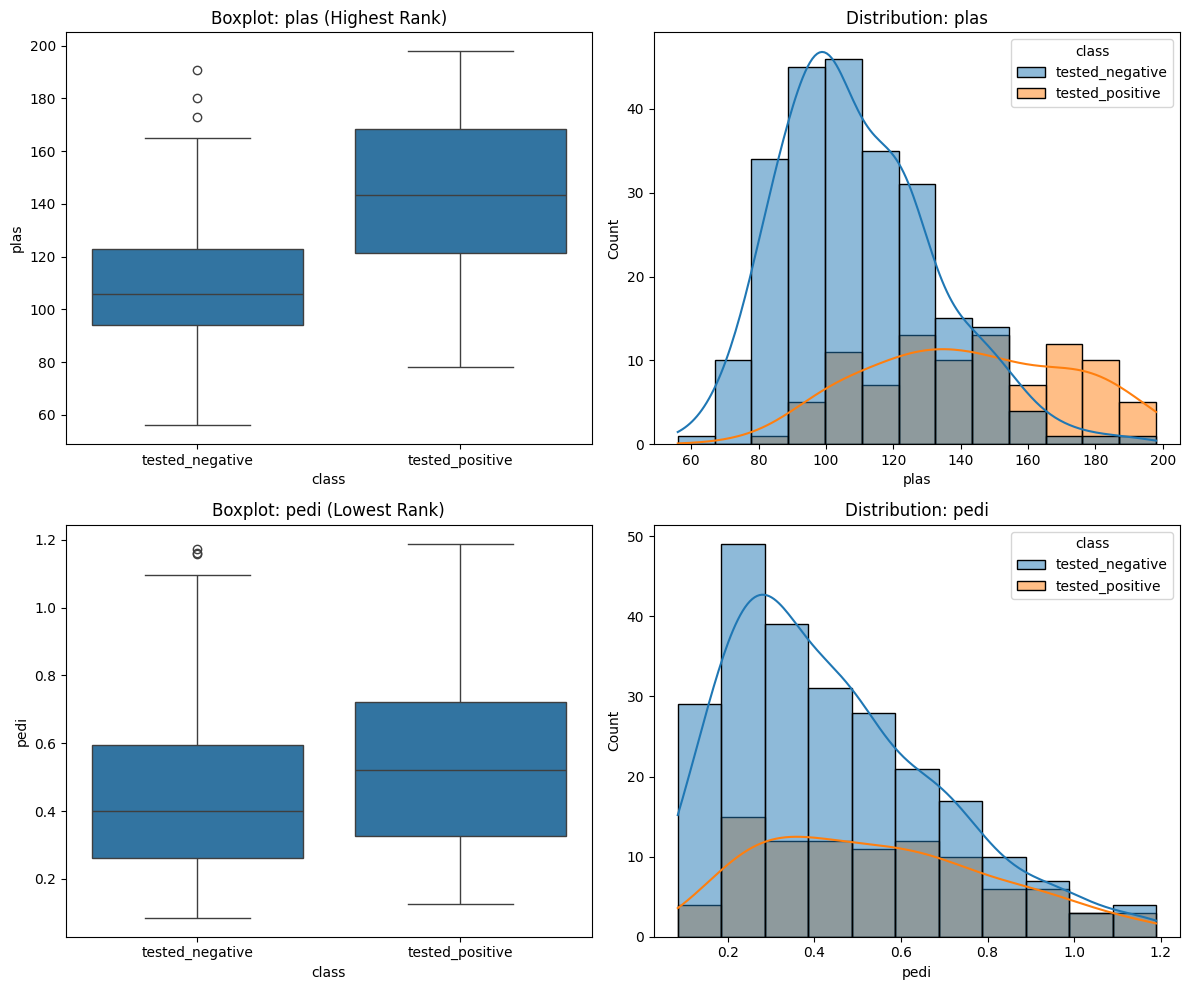

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify the top and bottom features from our previous ranking
top_feature = feature_ranks.index[0]
bottom_feature = feature_ranks.index[-1]

# Set up the figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Boxplot for the Top Feature
sns.boxplot(data=df_final, x='class', y=top_feature, ax=axes[0, 0])
axes[0, 0].set_title(f'Boxplot: {top_feature} (Highest Rank)')

# 2. Distribution Plot (Histogram) for the Top Feature
sns.histplot(data=df_final, x=top_feature, hue='class', kde=True, ax=axes[0, 1])
axes[0, 1].set_title(f'Distribution: {top_feature}')

# 3. Boxplot for the Bottom Feature
sns.boxplot(data=df_final, x='class', y=bottom_feature, ax=axes[1, 0])
axes[1, 0].set_title(f'Boxplot: {bottom_feature} (Lowest Rank)')

# 4. Distribution Plot for the Bottom Feature
sns.histplot(data=df_final, x=bottom_feature, hue='class', kde=True, ax=axes[1, 1])
axes[1, 1].set_title(f'Distribution: {bottom_feature}')

plt.tight_layout()
plt.show()